
# Do LLMs know the difference between a pet chicken and a roast chicken?

## Word sense disambiguation in computational models and humans


In human language, words do not always have a fixed meaning. The most striking example is homonymous words: words that have the same form, but very different meanings. For instance, the word "bank", which has a different meaning in the context "I went to the bank to get some money" and "At the river bank, I met my old friend". Polysemous words are words that have different -- yet related -- meanings: for example, "chicken" is the same 'entity' in "My pet chicken is lovely" and "I am having roast chicken for dinner", but has very different meanings in these two contexts. In general, context can modulate almost any word's meaning. This poses a challenge in computational linguistics, as we need to find a way to differentiate among different meanings like humans do. Much research, resources, and models have been put forward to help with this challenge.

In this assignment, you are going to focus on [Trott and Bergen's (2021)](https://aclanthology.org/2021.acl-long.550/) RAW-C dataset: you are going to conduct a number of explorations with this dataset and partially replicate their research by the end of the assignment. In short, the authors explore how good LLMs are at capturing same/different meanings of words across contexts by comparing it to human judgements. To better understand the idea and the research, start by reading the paper.

This assignment entails a series of (interconnected) tasks (altogether worth 95 points):

* **Task 1**. Compute contextual word embeddings at different layers from Trott & Bergen's dataset. Here, each word is found in 4 sentences: 2 with one meaning, 2 with another meaning.
* **Task 2**. Compute sense embeddings for words in Trott & Bergen's dataset using WordNet, so you have an embedding for each definition of the word.
* **Task 3**. Compute the similarity between the contextual word embeddings of the homonyms at different layers and their sense embeddings; explore the relationship between homonyms and dominant senses quantitatively and qualitatively
* **Task 4**. Replicate part of Trott & Bergen's work by computing similarities across sentences with same/different meanings at the different layers and correlate with human similarities; visualise the results and reflect on them

In order to better understand the assignment, we recommend going through it all before starting so that it is clear how each part is connected to the next (which will help you make decisions about data structures, for instance).

# Task 1: Compute contextual word embeddings for homonyms [20 points]

## Task 1.1: read, explore and extract the necessary data [5 points]

First, you will have to (fork and) clone the github repository that stores the data you'll need. This can be found here: https://github.com/sashakenjeeva/raw-c . The repo also includes a README with a description of the original files in the repository, as well as some notes relevant for this assignment specifically.

Make sure you mount the drive now so that you have access to the folder (think about setting the working directory in a way that is convenient).

In [930]:
import os
from pathlib import Path
import pandas as pd

# Create a mount to the project root
PROJECT_ROOT = Path(os.getcwd())

print(f"=== Project root: ===\n{PROJECT_ROOT}\n")

# Create a data path
DATA_PATH = PROJECT_ROOT / "data"

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH, exist_ok=True)

print(f"=== Data path: ===\n{DATA_PATH}\n")

# Get the RAW-C dataset
df_raw_c = pd.read_csv("https://raw.githubusercontent.com/sashakenjeeva/raw-c/main/data/processed/raw-c.csv")

# Save the RAW-C dataset in the data directory
df_raw_c.to_csv(DATA_PATH / "raw-c.csv")

=== Project root: ===
/Users/kazikgarstecki/Desktop/university/comp_ling_assignment

=== Data path: ===
/Users/kazikgarstecki/Desktop/university/comp_ling_assignment/data



Now, you will have to read the data and organise it in a structure that works for the next parts of the assignment.

Read and explore the dataframe to see its structure (print part of it). What we need from it are the homonyms (in the form that they appear in the sentence -- the lexeme -- and in their regular form -- the lemma) and their corresponding sentences with different meanings (M1_a and M1_b have same meaning; M2_a, M2_b have same meaning). We only will need the stimuli that are in the final RAW-C dataset, as this is what we'll replicate at the end.

You can decide which data structure to use, but make sure that all these pieces of information are there (the word, the string, the meaning id, and the corresponding sentences) and easy to retrieve. Show your data at the end, as well as how many stimuli you end up with.

In [931]:
import pandas as pd

# Load the dataset
df_rawc = pd.read_csv(DATA_PATH / "raw-c.csv")

# Explore the dataset
print(f"=== Dataframe shape: ===\n{df_rawc.shape}\n")
print(f"=== Dataframe types: ===\n{df_rawc.dtypes}\n")

=== Dataframe shape: ===
(672, 21)

=== Dataframe types: ===
Unnamed: 0                int64
word                        str
sentence1                   str
sentence2                   str
same                       bool
ambiguity_type              str
disambiguating_word1        str
disambiguating_word2        str
version                     str
Class                       str
mean_relatedness        float64
median_relatedness      float64
diff                    float64
count                     int64
sd_relatedness          float64
distance_bert           float64
distance_elmo           float64
se_relatedness          float64
v1                          str
v2                          str
string                      str
dtype: object



In [932]:
print(f"=== Dataframe description: ===")
df_rawc.info()

=== Dataframe description: ===
<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            672 non-null    int64  
 1   word                  672 non-null    str    
 2   sentence1             672 non-null    str    
 3   sentence2             672 non-null    str    
 4   same                  672 non-null    bool   
 5   ambiguity_type        672 non-null    str    
 6   disambiguating_word1  672 non-null    str    
 7   disambiguating_word2  672 non-null    str    
 8   version               672 non-null    str    
 9   Class                 672 non-null    str    
 10  mean_relatedness      672 non-null    float64
 11  median_relatedness    672 non-null    float64
 12  diff                  672 non-null    float64
 13  count                 672 non-null    int64  
 14  sd_relatedness        672 non-null    float64
 15  dis

In [933]:
# Declare important columns
columns_of_interest = [
    "word", 
    "string",
    "sentence1",
    "sentence2",
    "v1",
    "v2",
]

# Filter for said columns and rename them
df_rawc_filtered = df_rawc[columns_of_interest] 
df_rawc_filtered = df_rawc_filtered.rename(columns={"word": "lemma", "string": "word"})

df_rawc_filtered.head(5)

,lemma,word,sentence1,sentence2,v1,v2
0,act,act,It was a desperate act.,It was a magic act.,M1_a,M2_a
1,act,act,It was a desperate act.,It was a comedic act.,M1_a,M2_b
2,act,act,It was a humane act.,It was a magic act.,M1_b,M2_a
3,act,act,It was a humane act.,It was a comedic act.,M1_b,M2_b
4,act,act,It was a desperate act.,It was a humane act.,M1_a,M1_b


In [934]:
df_rawc_sentence_split = (
    pd.concat(
        [   
            # Take the 1st version/sentences 
            df_rawc_filtered[["lemma", "word", "sentence1", "v1"]].rename(
                columns={"sentence1": "sentence", "v1": "v"}
            ),
            # Take the 2nd version/sentences 
            df_rawc_filtered[["lemma", "word", "sentence2", "v2"]].rename(
                columns={"sentence2": "sentence", "v2": "v"}
            )
        ]
    )
    # Drop duplicates
    .drop_duplicates(subset=["lemma", "word", "sentence"])
    .reset_index(drop=True)
)

# Sort values for the sake of visualization
df_rawc_sentence_split.sort_values(axis=0, by=["lemma", "v"], inplace=True, ignore_index=True)

print(f"=== Dataframe shape: ===\n{df_rawc_sentence_split.shape}\n")
print(f"=== Unique items: ===\n{df_rawc_sentence_split.nunique()}\n")

PROCESSED_DATA = DATA_PATH / "processed"
if not os.path.exists(PROCESSED_DATA):
    os.makedirs(PROCESSED_DATA, exist_ok=True)
    
df_rawc_sentence_split.to_csv(PROCESSED_DATA / "raw_c_sentence_split.csv", index=False)

# Inspect the dataframe
df_rawc_sentence_split.head(5)

=== Dataframe shape: ===
(448, 4)

=== Unique items: ===
lemma       112
word        112
sentence    448
v             4
dtype: int64



,lemma,word,sentence,v
0,act,act,It was a desperate act.,M1_a
1,act,act,It was a humane act.,M1_b
2,act,act,It was a magic act.,M2_a
3,act,act,It was a comedic act.,M2_b
4,appeal,appeal,He had a universal appeal.,M1_a


## Task 1.2: Compute the contextualised word embeddings [15 points]


Now that you have the homonyms and their corresponding sentences, we will need to compute word embeddings for each of them. For this we will use the BERT base model, in its uncased version.

That is, for each homonym, you will have to compute four embeddings: one for the homonym in M1_a, one in M1_b, one in M2_a, one in M2_b. However, we also want to look into different layers of the BERT model to see which one captures the homonym's meaning best: you want to calculate embeddings at the static layer and at layers 4, 8, 12.

We will use the package psycho-embeddings (you will use it in class), which allows us to specify which target words we want to obtain the embeddings of, in which sentences, and at which layers, among other things. Make sure to read the documentation of the package so that you know the meaning of the arguments and which ones will come useful to you.

First of all, install the psycho-embeddings package below.

In [935]:
# install the psycho-embeddings package here

# Clone the repository
if not os.path.exists(PROJECT_ROOT / "psycho-embeddings"):
    !git clone https://github.com/MilaNLProc/psycho-embeddings

# Uncomment depending on the package manager you are using
# !pip install -e . 
!uv pip install -e .

Resolved 43 packages in 532ms                                        
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/university/c
   Building comp-ling-assignment @ file:///Users/kazikgarstecki/Desktop/universi

Now, import the relevant module/function from psycho-embeddings and load the required BERT model.

In [936]:
# your code here
from psycho_embeddings import ContextualizedEmbedder

# Load model
bert_model = ContextualizedEmbedder("bert-base-uncased", max_length=128)

loading configuration file config.json from cache at /Users/kazikgarstecki/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.5.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file model.

Now, test that everything works correctly by computing an embedding for the word "assignment" in the sentence "I am having so much fun with this assignment!", at static layer and layers 4, 8 and 12 (hint: think of tokenisation and how the embedder deals with that).

In [937]:
import numpy as np

test_embeddings = bert_model.embed(
    words=["assignment"],
    target_texts=["I am having so much fun with this assignment!"],
    layers_id=[4, 8, 12],
    batch_size=8,
    return_static=True,
)

layer_idx = [(-1, "static"), (4, "4"), (8, "8"), (12, "12")]

for idx, layer in layer_idx:
    print(f"\n=== Layer {layer} Embedding: ===")
    emb = test_embeddings[idx][0]
    print(f"type: {type(emb)}")
    print(f"shape: {emb.shape}")

  0%|          | 0/1 [00:00<?, ?it/s]/Users/kazikgarstecki/Desktop/university/comp_ling_assignment/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1/1 [00:00<00:00, 12.99it/s]


=== Layer static Embedding: ===
type: <class 'numpy.ndarray'>
shape: (768,)

=== Layer 4 Embedding: ===
type: <class 'numpy.ndarray'>
shape: (768,)

=== Layer 8 Embedding: ===
type: <class 'numpy.ndarray'>
shape: (768,)

=== Layer 12 Embedding: ===
type: <class 'numpy.ndarray'>
shape: (768,)


The next step is to calculate embeddings for the homonyms and their sentences that we got from the RAW-C dataset.

Make sure that your final output includes the word, the meaning id (M1_a, etc), the corresponding sentence and the embeddings at static layer and layers 4, 8, 12. You should maximally optimise this process by calculating in batches (again, check psycho-embeddings documentation), but keep in mind this might still take a while. First test your pipeline with a small number of inputs, and only run the full scale embedding extraction once you're positive the code works as expected.

When done, save the output in [pickle](https://docs.python.org/3/library/pickle.html) format (this is similar to json, but it can also handle np.arrays), so that you can easily load it later when needed and do not have to run it again. After pickle dumping (that's the word for saving it in pickle format), print it so that you are sure everything was saved correctly.

Then, check that your final data includes everything that you need by checking the entry "bank" and print the data pertaining to "bank".

In [938]:
# Calculate embeddings for homonyms and their sentences
test_raw_c_embeddings = bert_model.embed(
    words = df_rawc_sentence_split["word"].tolist(),
    target_texts = df_rawc_sentence_split["sentence"].tolist(),
    layers_id = [4, 8, 12],
    batch_size = 32,
    return_static = True
)

# Map emb dict keys to column names
emb_key_layer_mapping = {
    4: "layer_4",
    8: "layer_8",
    12: "layer_12",
    -1: "layer_static"
}

# Ensure no changes are applied to previous dataframe
df_rawc_with_embeddings = df_rawc_sentence_split.copy(deep=True)

# Include embeddings as part of the new dataframe
for key, layer in emb_key_layer_mapping.items():
    df_rawc_with_embeddings[layer] = test_raw_c_embeddings[key]

# Save as pickle
df_rawc_with_embeddings.to_pickle(PROCESSED_DATA / "raw_c_with_embeddings.pkl")
# Load to ensure everything went well
df_rawc_with_embeddings = pd.read_pickle(PROCESSED_DATA / "raw_c_with_embeddings.pkl")

# Confirm that embeddings are saved as numpy arrays
random_embedding = df_rawc_with_embeddings.iloc[0]["layer_static"]
assert isinstance(random_embedding, np.ndarray)

# Inspect the new dataframe
df_rawc_with_embeddings.head(5)

  0%|          | 0/14 [00:00<?, ?it/s]/Users/kazikgarstecki/Desktop/university/comp_ling_assignment/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 14/14 [00:09<00:00,  1.53it/s]


,lemma,word,sentence,v,layer_4,layer_8,layer_12,layer_static
0,act,act,It was a desperate act.,M1_a,"[1.6829053, 0.08441312, -0.33193615, -0.341306...","[1.0654582, -0.36254317, 0.1188567, 0.13084409...","[0.3789006, -0.21466061, -0.057178605, -0.1951...","[0.017291509, 0.01293602, -0.053804133, -0.061..."
1,act,act,It was a humane act.,M1_b,"[1.5745126, -0.53692955, -0.36310813, -0.64165...","[1.5665528, -0.40207732, 0.26410484, 0.0026419...","[0.30742064, -0.411638, -0.10526247, -0.319348...","[0.017291509, 0.01293602, -0.053804133, -0.061..."
2,act,act,It was a magic act.,M2_a,"[1.9441345, 0.028225563, -0.33929366, -0.99731...","[1.6207538, -0.3879069, 0.40122306, -0.4561103...","[0.9379027, 0.039944846, 0.2086345, -0.2862577...","[0.017291509, 0.01293602, -0.053804133, -0.061..."
3,act,act,It was a comedic act.,M2_b,"[0.86945885, -0.2438263, 0.01976711, -0.857342...","[0.78628355, -0.5734637, 0.53356946, -0.123716...","[0.06930962, -0.06950791, -0.2661462, -0.33356...","[0.017291509, 0.01293602, -0.053804133, -0.061..."
4,appeal,appeal,He had a universal appeal.,M1_a,"[1.0649076, -0.9980851, -0.43838885, -1.073057...","[0.73011875, 0.18825388, 0.60285467, -0.466076...","[0.46518275, -0.09599658, 0.2225516, -0.109499...","[-0.028775984, -0.080165826, -0.023797046, -0...."


# Task 2: Compute sense embeddings for the homonym dataset using WordNet [20 points]

Your next task is to fetch the definitions (glosses) of the homonyms, and compute an embedding for each gloss (each gloss is associated with a specific sense). We do that so we can later see whether the contextualised embeddings computed above represent the meaning of the homonym in context well (by comparing it to the sense embeddings). Figure 18.9 in [Jurafsky's and Martin's (2021) chapter 18](https://web.stanford.edu/~jurafsky/slp3/old_sep21/18.pdf) graphically illustrates this idea. Use this chapter for this part of the assignment, as it will come useful for you both theoretically and practically.

## Task 2.1: Fetch senses and glosses for a word [5 points]

First of all, you will have to figure out how [WordNet](https://www.nltk.org/howto/wordnet.html) works within the nltk package (hint: pay attention to what a synset is).

Install and import all the necessary components and define a function to extract the glosses of a word and create a dictionary with senses and glosses.

Then use the word "bat" to test that everything is working correctly: i.e., for "bat", you should be able to get its senses and the gloss for each of the sense (you will see that synsets might contain related words, but you only need the senses that contain the word of interest or derivates thereof; this should be specified in the function). Print the output for "bat".


In [939]:
# your code here
import nltk

# Download wordnet
nltk.download("wordnet")
from nltk.corpus import wordnet as wn

def get_senses_and_glosses(word):
    temp_dict = {
        "word": [],
        "synset": [],
        "gloss": [],
    }

    for synset in wn.synsets(word):
        # Retreive the gloss
        gloss = synset.definition()

        sense = synset.name()

        # Check if the sense 
        if sense.split(".")[0].startswith(word):
            temp_dict["word"].append(word)
            temp_dict["synset"].append(sense)
            temp_dict["gloss"].append(gloss)
    
    return temp_dict

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kazikgarstecki/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [940]:
# Retrieve bat synsets
bat_synsets = get_senses_and_glosses("bat")

# Print bat output
for synset, gloss in zip(bat_synsets["synset"], bat_synsets["gloss"]):
    print(f"{synset}: {gloss}")

bat.n.01: nocturnal mouselike mammal with forelimbs modified to form membranous wings and anatomical adaptations for echolocation by which they navigate
bat.n.02: (baseball) a turn trying to get a hit
bat.n.05: a club used for hitting a ball in various games
bat.v.01: strike with, or as if with a baseball bat
bat.v.02: wink briefly
bat.v.03: have a turn at bat
bat.v.04: use a bat


## Task 2.2: Function to compute sense embeddings [10 points]

Now that you have a function to extract senses and glosses for a given word, write a function that takes a word and computes embeddings for each of the senses following the method explained in Jurafsky's and Martin's chapter. In this case, no need to calculate at different layers: you should use the last layer only. You should maximally optimise this function like before.

The output should include the sense, the gloss, and the embedding. Print the function's output when using the word "bank".


In [941]:
def retrieve_sense_embeddings(
    lemma_list: str | list[str], 
    get_senses_and_glosses_func = get_senses_and_glosses, 
    model: ContextualizedEmbedder = bert_model,
    LAST_LAYER_IDX: int = 12
):
    all_lemmas = []
    all_glosses = []
    all_synsets = []
    words_to_embed = []
    target_texts_to_embed = []    

    if isinstance(lemma_list, str):
        lemma_list = [lemma_list]
    
    for lemma in lemma_list:
        # Retrieve the senses and glosses
        lemma_synset = get_senses_and_glosses_func(lemma)
        synsets, glosses = lemma_synset["synset"], lemma_synset["gloss"]
        all_lemmas.extend([lemma] * len(glosses))
        all_glosses.extend(glosses)
        all_synsets.extend(synsets)

        # Append them to the lists later passed to the embedder
        words_to_embed.extend([synset.split(".")[0] for synset in synsets])
        # NOTE: the target texts will always follow the form: f"{sense}: {gloss}"
        target_texts_to_embed.extend([f"{sense.split(".")[0]}: {gloss}" for sense, gloss in zip(synsets, glosses)])

    sense_embeddings = model.embed(
        words=words_to_embed,
        target_texts=target_texts_to_embed,
        layers_id=[LAST_LAYER_IDX],
        batch_size=16,
        return_static=False
    )
    
    return {
        "lemma": all_lemmas,
        "synset": all_synsets,
        "sense": words_to_embed,
        "gloss": all_glosses,
        "embedding": sense_embeddings[LAST_LAYER_IDX]
    }

In [942]:
# Run the sense embeddding function on the word "bank"
bank_sense_embeddings = retrieve_sense_embeddings("bank")

# Visualize the output
pd.DataFrame().from_dict(bank_sense_embeddings)

  0%|          | 0/1 [00:00<?, ?it/s]/Users/kazikgarstecki/Desktop/university/comp_ling_assignment/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 1/1 [00:00<00:00,  3.48it/s]


,lemma,synset,sense,gloss,embedding
0,bank,bank.n.01,bank,sloping land (especially the slope beside a bo...,"[0.12150506, -0.14082775, -0.24302498, -0.2460..."
1,bank,bank.n.03,bank,a long ridge or pile,"[0.031304292, -0.22398716, -0.5094195, -0.4397..."
2,bank,bank.n.04,bank,an arrangement of similar objects in a row or ...,"[0.31977126, -0.23580891, -0.7017689, 0.142542..."
3,bank,bank.n.05,bank,a supply or stock held in reserve for future u...,"[0.42835185, -0.33511797, -0.57390106, 0.07775..."
4,bank,bank.n.06,bank,the funds held by a gambling house or the deal...,"[-0.0022778758, 0.012502015, -0.72262394, -0.0..."
5,bank,bank.n.07,bank,a slope in the turn of a road or track; the ou...,"[-0.041520525, -0.21230876, -0.29962787, -0.32..."
6,bank,bank.n.09,bank,a building in which the business of banking tr...,"[0.4822492, 0.019960396, -0.3508716, -0.172362..."
7,bank,bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985..."
8,bank,bank.v.01,bank,tip laterally,"[-0.17739385, -0.20971015, -0.47318688, -0.137..."
9,bank,bank.v.02,bank,enclose with a bank,"[0.28713334, 0.033689097, -0.33909184, -0.1865..."


## Task 2.3: Compute sense embeddings for the RAW-C stimuli [5 points]

Now, use the function you defined above to compute sense embeddings for the RAW-C stimuli and pickle dump it too.

As above, the information that should be there for each word is: the sense, the gloss, the embedding at the last layer. Again, you can think of which structure to use best, but keep in mind that we will have to compare these to the CWE calculated in task 1, so it is good to think of a similar structure that is easily comparable.

Make sure that the number of stimuli matches the number of stimuli in the final RAW-C dataset.

In [943]:
# Retrieve unique lemmas
raw_c_lemmas = df_rawc_with_embeddings["lemma"].unique().tolist()
# Make sure the number of stimuli checks out 
assert len(raw_c_lemmas) == 112

# Extract sense embeddings for RAW-C stimuli
raw_c_sense_embeddings = retrieve_sense_embeddings(raw_c_lemmas)
# Create a dataframe from the function output
df_raw_c_sense_embeddings = pd.DataFrame().from_dict(raw_c_sense_embeddings)

# Make sure the number of stimuli after checks out
raw_c_sense_lemmas = df_raw_c_sense_embeddings["lemma"].unique().tolist()
assert len(raw_c_lemmas) == len(raw_c_sense_lemmas)

# Save the sense embeddings as a pickle
df_raw_c_sense_embeddings.to_pickle(PROCESSED_DATA / "raw_c_sense_embeddings.pkl")

  0%|          | 0/64 [00:00<?, ?it/s]/Users/kazikgarstecki/Desktop/university/comp_ling_assignment/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 64/64 [00:18<00:00,  3.48it/s]


# Task 3: Compute and explore similarity between homonym CWEs and sense embeddings [35 points]

You now have the homonym CWEs computed in task 1, and the sense embeddings computed in task 2. The next step is to calculate cosine similarities between each CWE for each homonym (at the selected layer!) and each sense embedding for that homonym.

For instance, say for the word "bat" with meaning M1_a, you have its CWE at the static layer and at layers 4, 8, 12 and 7 senses: here, you will end up with 16 cosine similarities (take each CWE and compute its similarity to each of the sense embeddings). We then want to see which sense meaning is the closest to each CWE, and do some qualitative explorations with that.

## Task 3.1: Compute the cosine similarity between all the CWEs and the sense embeddings [8 points]

This task is not trivial with regards to how much information you have and how to structure the data (this is why it's also important to think of data structures in the earlier parts of the assignment), so take some time to think how to best breakdown this task. Test each step/function if you have multiple. Pickle dump your final output so that it is easily retrievable for later. At the end, print an example of the entry "bank".

For cosine similarity, the cdist function from scipy.spatial.distance seems the most efficient, but you are free to use any of your liking (hint: pay attention to the shape of your embeddings and to similarity vs distance. You will need the similarity).

In [944]:
from sklearn.metrics.pairwise import cosine_similarity

lemma_list = []
word_list = []
sentence_list = []
v_list = []
cwe_layer_list = []
cwe_emb_list = []
synset_list = []
sense_list = []
gloss_list = []
sense_emb_list = []
cos_sim_list = []

for _, row in df_rawc_with_embeddings.iterrows():
    # Load data into vars
    lemma = row["lemma"]
    word = row["word"]
    sentence = row["sentence"]
    v = row["v"]

    cwe_embeddings = {
        "static": row["layer_static"],
        "4": row["layer_4"],
        "8": row["layer_8"],
        "12": row["layer_12"]
    }

    # Retrieve sense embeddings for relevant lemma
    sense_filter = df_raw_c_sense_embeddings["lemma"] == row["lemma"]
    sense_emb_df = df_raw_c_sense_embeddings[sense_filter]

    synsets, senses, glosses, sense_embeddings = sense_emb_df["synset"], sense_emb_df["sense"].tolist(), sense_emb_df["gloss"].tolist(), sense_emb_df["embedding"].tolist()

    # Compare each CWE for each lemma meaning to all sense embeddings and store the cosine similarities
    for ly, cwe_emb in cwe_embeddings.items():
        for synset, sense, gloss, sense_emb in zip(synsets, senses, glosses, sense_embeddings):
            reshaped_cwe_emb, reshaped_sense_emb = cwe_emb.reshape(1, -1), sense_emb.reshape(1, -1)
            cos_sim = cosine_similarity(reshaped_cwe_emb, reshaped_sense_emb).item()

            lemma_list.append(lemma)
            word_list.append(word)
            sentence_list.append(sentence)
            v_list.append(v)
            cwe_layer_list.append(ly)
            cwe_emb_list.append(cwe_emb)
            synset_list.append(synset)
            sense_list.append(sense)
            gloss_list.append(gloss)
            sense_emb_list.append(sense_emb)
            cos_sim_list.append(cos_sim)

# Create the dataframe from the results
df_raw_c_cwe_sense_emb_cos_similarities = pd.DataFrame({
    "lemma": lemma_list,
    "word": word_list,
    "sentence": sentence_list,
    "v": v_list,
    "cwe_layer": cwe_layer_list,
    "cwe_emb": cwe_emb_list,
    "synset": synset_list,
    "sense": sense_list,
    "gloss": gloss_list,
    "sense_emb": sense_emb_list,
    "cos_sim": cos_sim_list
})

# Save the dataframe as a pickle
df_raw_c_cwe_sense_emb_cos_similarities.to_pickle(PROCESSED_DATA / "raw_c_cwe_sense_emb_cos_similarities.pkl")

# Inspect the data
df_raw_c_cwe_sense_emb_cos_similarities.head()

,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim
0,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.01,act,a legal document codifying the result of delib...,"[0.78000736, -0.5004632, -0.35106277, -0.74719...",0.142451
1,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.02,act,something that people do or cause to happen,"[0.43565655, -0.38396898, -0.6966581, -0.20040...",0.151373
2,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635
3,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.04,act,a short theatrical performance that is part of...,"[0.20125636, -0.4539132, -0.36038178, -0.40815...",0.173200
4,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.05,act,a manifestation of insincerity,"[0.3635703, -0.16950282, -0.36749712, -0.19376...",0.135901


## Task 3.2: Quantitative and qualitative explorations the relationship between homonym embeddings and dominant senses

Now, we can look into how the CWEs in different meanings and layers relate to the different senses of a homonym. We'll focus on the dominant sense in WordNet, see below for more details. This section includes both code blocks and reflection questions.

### Dominant senses in WordNet and top senses across layers (focus on static layer) [8 points]

Embeddings at the static layer do not take into account context, so intuitively they should capture the 'average' meaning, maybe the most common/dominant. We can test this by looking at the most similar sense and seeing if that matches that most common/dominant sense in the synset.

Keep in mind that synsets mark more common/dominant senses with numbering: so n.01 will be the most common noun; v.01 the most common verb, etc. If that is not available, the most common meaning will be the next number (e.g., n.02). You have to take that into account when you extract the top sense, so first extract information about which are the most dominant senses for each word across all the parts of speech: for example, "bat" might have as its two most common senses bat.n.01 and bat.v.02 (because v.01 might not be available; this is just an example). Some words might only have one part of speech in their synset, some more. Print your results.

In [945]:
# your code here
parts_of_speech = ['n', 'v', 's', 'a', 'r']

def extract_dominant_senses(word: str, parts_of_speech: list[str] = parts_of_speech):
    dominant_pos = {}
    for synset in wn.synsets(word):
        name_split = synset.name().split(".")
        pos, n = name_split[1], int(name_split[2])
        if pos not in dominant_pos.keys():
            dominant_pos[pos] = (n, synset.definition())
        elif n < dominant_pos[pos][0]:
            dominant_pos[pos] = (n, synset.definition())

    formatted_dict = {
        pos: definition for pos, (_, definition) in zip(dominant_pos.keys(), dominant_pos.values())
    }  
    
    for pos in parts_of_speech:
        if pos not in formatted_dict.keys():
            formatted_dict[pos] = None

    return formatted_dict

for pos, dom_gloss in extract_dominant_senses("bat").items():
    print(f"{pos}: {dom_gloss}")

n: nocturnal mouselike mammal with forelimbs modified to form membranous wings and anatomical adaptations for echolocation by which they navigate
v: strike with, or as if with a baseball bat
s: None
a: None
r: None


In [946]:
# Extract dominant senses for each lemma
dominant_by_lemma = {
    lemma: set(extract_dominant_senses(lemma).values())
    for lemma in df_raw_c_cwe_sense_emb_cos_similarities["lemma"].unique()
}

# Then include that information in the dataframe
df_raw_c_cwe_sense_emb_cos_similarities["is_sense_dominant"] = df_raw_c_cwe_sense_emb_cos_similarities.apply(
    lambda r: r["gloss"] in dominant_by_lemma[r["lemma"]], 
    axis=1
)

# Visualize
df_raw_c_cwe_sense_emb_cos_similarities[df_raw_c_cwe_sense_emb_cos_similarities["lemma"] == "bat"].head()

,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim,is_sense_dominant
896,bat,bat,He saw a furry bat.,M1_a,static,"[-0.00869182, -0.03965187, -0.023992054, -0.03...",bat.n.01,bat,nocturnal mouselike mammal with forelimbs modi...,"[-0.11680403, 0.3896435, -0.8748058, -0.459466...",0.154604,True
897,bat,bat,He saw a furry bat.,M1_a,static,"[-0.00869182, -0.03965187, -0.023992054, -0.03...",bat.n.02,bat,(baseball) a turn trying to get a hit,"[0.61385465, -0.14308572, -0.037613828, -0.861...",0.198000,False
898,bat,bat,He saw a furry bat.,M1_a,static,"[-0.00869182, -0.03965187, -0.023992054, -0.03...",bat.n.05,bat,a club used for hitting a ball in various games,"[0.85283846, -0.22426552, 0.08675102, -0.59471...",0.218353,False
899,bat,bat,He saw a furry bat.,M1_a,static,"[-0.00869182, -0.03965187, -0.023992054, -0.03...",bat.v.01,bat,"strike with, or as if with a baseball bat","[1.0021492, -0.3215391, -0.16373613, -0.814565...",0.188003,True
900,bat,bat,He saw a furry bat.,M1_a,static,"[-0.00869182, -0.03965187, -0.023992054, -0.03...",bat.v.02,bat,wink briefly,"[0.23820482, -0.29097497, -0.50572044, -0.5886...",0.212196,False


Then, extract the top similarity of homonyms to the senses at all the layers you have available. While we are interested in the static layer for checking dominant senses, it is also interesting to look into other layers to see whether adding context will refine the captured meaning.


In [947]:
# Retrieve highest cosine similarity scores for each CWE x sense comparison 
df_top_cwe_sense_emb_match = df_raw_c_cwe_sense_emb_cos_similarities.loc[
    df_raw_c_cwe_sense_emb_cos_similarities
    .groupby(["lemma", "v", "cwe_layer"])["cos_sim"].idxmax()
]

df_top_cwe_sense_emb_match.head(5)

,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim,is_sense_dominant
41,act,act,It was a desperate act.,M1_a,12,"[0.3789006, -0.21466061, -0.057178605, -0.1951...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.363632,False
15,act,act,It was a desperate act.,M1_a,4,"[1.6829053, 0.08441312, -0.33193615, -0.341306...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.307150,False
28,act,act,It was a desperate act.,M1_a,8,"[1.0654582, -0.36254317, 0.1188567, 0.13084409...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.319136,False
2,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635,False
93,act,act,It was a humane act.,M1_b,12,"[0.30742064, -0.411638, -0.10526247, -0.319348...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.403991,False


Let's check an example from our results.

Out of all the similarities of 'bank' to all its senses at all the layers, which one is the highest? Print your results for that entry and reflect below.

In [948]:
dom_bank_sense_wn = extract_dominant_senses("bank")
print(f"=== Dominant senses of the word \"bank\" (according to WordNet): ===")
for pos, sense in dom_bank_sense_wn.items():
    if sense:
        print(f"Sense: {sense} | POS: {pos}")
print()

static_bank_gloss = df_top_cwe_sense_emb_match[
    (df_top_cwe_sense_emb_match["lemma"] == "bank") &
    (df_top_cwe_sense_emb_match["cwe_layer"] == "static")
][["gloss", "is_sense_dominant"]].drop_duplicates(subset=["gloss"])
print(f"=== The static layer representation for \"bank\" (according to BERT) has the closest match to gloss: ===")
print(f"Gloss: {static_bank_gloss["gloss"].item()}")
print(f"Is this the dominant sense (according to WordNet)? A: {static_bank_gloss["is_sense_dominant"].item()}\n")


# Retrieve info about the highest similarity yielding sense for the word "bank"
lemma, word, sentence, gloss, cwe_layer = df_top_cwe_sense_emb_match.loc[
    df_top_cwe_sense_emb_match[df_top_cwe_sense_emb_match["lemma"] == "bank"]["cos_sim"].idxmax()
][["lemma", "word", "sentence", "gloss", "cwe_layer"]]

print(f"=== Lemma: {lemma} ===")
print(f"=== Word in Text: {word} ===")
print(f"=== Context: {sentence} ===")
print(f"=== Gloss: {gloss} ===")
print(f"=== At Layer: {cwe_layer} ===")

df_top_cwe_sense_emb_match[df_top_cwe_sense_emb_match["lemma"] == "bank"]

=== Dominant senses of the word "bank" (according to WordNet): ===
Sense: sloping land (especially the slope beside a body of water) | POS: n
Sense: tip laterally | POS: v

=== The static layer representation for "bank" (according to BERT) has the closest match to gloss: ===
Gloss: act as the banker in a game or in gambling
Is this the dominant sense (according to WordNet)? A: False

=== Lemma: bank ===
=== Word in Text: banked ===
=== Context: He banked the money. ===
=== Gloss: the funds held by a gambling house or the dealer in some gambling games ===
=== At Layer: 12 ===


,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim,is_sense_dominant
673,bank,banked,He banked the plane.,M1_a,12,"[0.47558218, -0.89308226, -0.009991892, 0.1354...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.257770,False
645,bank,banked,He banked the plane.,M1_a,4,"[0.5385525, -0.662948, -1.5406694, -0.06089593...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.301040,False
659,bank,banked,He banked the plane.,M1_a,8,"[0.62526256, -0.5338886, -0.68295956, 0.146766...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.357209,False
635,bank,banked,He banked the plane.,M1_a,static,"[-0.01913044, -0.06455895, -0.091287486, -0.07...",bank.v.04,bank,act as the banker in a game or in gambling,"[0.31823957, -0.21817034, -0.6977838, -0.22398...",0.260034,False
729,bank,banked,He banked the helicopter.,M1_b,12,"[0.34683716, -0.4219114, 0.06967187, -0.096643...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.295826,False
701,bank,banked,He banked the helicopter.,M1_b,4,"[0.4195775, -0.6558981, -1.3800256, -0.1345121...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.325868,False
715,bank,banked,He banked the helicopter.,M1_b,8,"[0.4546544, -0.3016109, -0.832405, -0.15307184...",bank.n.10,bank,a flight maneuver; aircraft tips laterally abo...,"[-0.04142214, -0.5214778, -0.1963114, -0.21985...",0.387237,False
691,bank,banked,He banked the helicopter.,M1_b,static,"[-0.01913044, -0.06455895, -0.091287486, -0.07...",bank.v.04,bank,act as the banker in a game or in gambling,"[0.31823957, -0.21817034, -0.6977838, -0.22398...",0.260034,False
782,bank,banked,He banked the money.,M2_a,12,"[0.25974402, -0.23209313, -0.64788705, -0.2467...",bank.n.06,bank,the funds held by a gambling house or the deal...,"[-0.0022778758, 0.012502015, -0.72262394, -0.0...",0.514350,False
754,bank,banked,He banked the money.,M2_a,4,"[0.46687046, 0.059844278, -1.0776862, 0.090100...",bank.n.06,bank,the funds held by a gambling house or the deal...,"[-0.0022778758, 0.012502015, -0.72262394, -0.0...",0.348735,False


### Does the static layer capture the most dominant meaning, according to WordNet (and according to you)? [2 points]

No, and interestingly, neither WordNet's dominant sense nor our own intuition agree with what the static layer captures.

BERT's static-layer nearest sense for "bank" is "act as the banker in a game or in gambling", a relatively rare usage. WordNet's dominant senses (the first-ranked sense per POS) are different: the dominant noun sense is "sloping land (especially the slope beside a body of water)" - the river-bank meaning - and the dominant verb sense is "tip laterally". Our own intuition would point to a third meaning entirely: "a financial institution", which we would consider the most common use of the word in modern English.

So three different "dominant" candidates emerge from three different sources. BERT's static embedding, WordNet's ordering, and a contemporary speaker's intuition, and none of them coincide. This is itself informative: it illustrates that "dominant sense" is not a single, well-defined concept but depends heavily on the underlying corpus or population whose usage is being measured.

### Across other layers and meanings, which layer seems to capture the meaning of bank across meanings best, and why do you make this conclusion? [2 points]

We measured how well each layer captures the contextually appropriate meaning of "bank" by comparing each CWE's cosine similarity to the WordNet sense embedding most closely matching the RAW-C-labelled meaning for that sentence. Higher similarity to the contextually appropriate sense indicates better meaning capture.

Across the four "bank" sentences, there is no single layer that consistently shows the highest similarity to the contextually appropriate sense. Instead, the pattern is broadly progressive: layer 4 already improves substantially over the static layer; layer 8 improves further; however, the improvement over layer 8 is not consistent at layer 12 (layer 12's behaviour is mixed: for 2 sentences it outperforms layer 8, for 2 it falls back below layer 4).

This pattern is consistent with the BERTology account discussed below: contextual integration peaks in the middle-to-upper layers, where syntactic and semantic information are most richly represented, while layer 12 begins to re-specialize toward the MLM token-prediction objective and may partially "lose" the contextual disambiguation that layer 8 achieved. For "bank" specifically, this means there is no single layer that best captures meaning across both senses, but layer 8 is the most consistent in providing better representation over predecessors.

### Checking matches and mismatches with the dominant sense [5 points]

Now, let's quantitatively check if the static layer actually captures the most dominant sense (any POS). You should end up with two data structures: matches (when the most similar sense is one of the dominant senses) and mismatches (when the most similar sense is not one of the dominant sense). Do that also for the other layers to compare. Print the percentage of matches and mismatches per layer.



In [949]:
# your code here

# Define function for splitting data into dominant sense matches/mismatches for a specified cwe_layer
def check_dom_sense_capture(df: pd.DataFrame, cwe_layer: str = "static"):
    df_dom_sense_capture = df[df["cwe_layer"] == cwe_layer]
    dom_sense_filter = df_dom_sense_capture["is_sense_dominant"] == True
    return (
        df_dom_sense_capture[dom_sense_filter], df_dom_sense_capture[~dom_sense_filter]
    )

# Retrieve the ratio of dominant senses to all senses to compare 
dom_sense_filter = df_raw_c_cwe_sense_emb_cos_similarities["is_sense_dominant"] == True
n_dominant_senses = df_raw_c_cwe_sense_emb_cos_similarities[dom_sense_filter]["gloss"].nunique()
n_all_glosses = df_raw_c_cwe_sense_emb_cos_similarities["gloss"].nunique()

print(f"=== Percent of dominant senses among all senses: ===")
print(
    f"{n_dominant_senses / n_all_glosses:.2f}%\n"
)

# Retrieve dominant sense match ratio for all layers
for cwe_layer in ["static", "4", "8", "12"]:
    print(f"=== Percent of dominant sense matches for layer: {cwe_layer} ===")
    df_matches, df_mismatches = check_dom_sense_capture(
        df_top_cwe_sense_emb_match, cwe_layer
    )
    print(f"{df_matches.shape[0] / df_mismatches.shape[0]:.2f}%\n")


=== Percent of dominant senses among all senses: ===
0.17%

=== Percent of dominant sense matches for layer: static ===
0.32%

=== Percent of dominant sense matches for layer: 4 ===
0.22%

=== Percent of dominant sense matches for layer: 8 ===
0.22%

=== Percent of dominant sense matches for layer: 12 ===
0.31%



Now, print the matches and mismatches for the static layer only.

In [950]:
# Retrieve match/mismatch dataframes for static layer only
df_static_matches, df_static_mismatches = check_dom_sense_capture(
    df_top_cwe_sense_emb_match, cwe_layer="static"
)

# Print percent of matches for static layer alone
print(f"=== Percent of matches for static layer: ===")
print(
    f"{df_static_matches.shape[0] / df_static_mismatches.shape[0]:.2f}%\n"
)

=== Percent of matches for static layer: ===
0.32%



In [951]:
# Print static layer matches dataframe 
df_static_matches.head()

,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim,is_sense_dominant
473,band,band,It was a gold band.,M1_a,static,"[0.024047647, 0.019853437, -0.036708716, -0.01...",band.v.01,band,"bind or tie together, as with a band","[0.80559963, -0.07751176, -0.008322455, -0.296...",0.233277,True
513,band,band,It was a rubber band.,M1_b,static,"[0.024047647, 0.019853437, -0.036708716, -0.01...",band.v.01,band,"bind or tie together, as with a band","[0.80559963, -0.07751176, -0.008322455, -0.296...",0.233277,True
553,band,band,It was a jazz band.,M2_a,static,"[0.024047647, 0.019853437, -0.036708716, -0.01...",band.v.01,band,"bind or tie together, as with a band","[0.80559963, -0.07751176, -0.008322455, -0.296...",0.233277,True
593,band,band,It was a country band.,M2_b,static,"[0.024047647, 0.019853437, -0.036708716, -0.01...",band.v.01,band,"bind or tie together, as with a band","[0.80559963, -0.07751176, -0.008322455, -0.296...",0.233277,True
2576,breakfast,breakfast,They ate a pancake breakfast.,M1_a,static,"[-0.01921527, 0.024265885, -0.05079318, -0.059...",breakfast.n.01,breakfast,the first meal of the day (usually in the morn...,"[0.012461613, 0.120756485, -0.45446745, -0.480...",0.247247,True


In [952]:
# Print static layer mismatches dataframe
df_static_mismatches.head()

,lemma,word,sentence,v,cwe_layer,cwe_emb,synset,sense,gloss,sense_emb,cos_sim,is_sense_dominant
2,act,act,It was a desperate act.,M1_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635,False
54,act,act,It was a humane act.,M1_b,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635,False
106,act,act,It was a magic act.,M2_a,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635,False
158,act,act,It was a comedic act.,M2_b,static,"[0.017291509, 0.01293602, -0.053804133, -0.061...",act.n.03,act,a subdivision of a play or opera or ballet,"[-0.26154134, -0.401941, -0.029744823, -0.6416...",0.224635,False
208,appeal,appeal,He had a universal appeal.,M1_a,static,"[-0.028775984, -0.080165826, -0.023797046, -0....",appeal.n.02,appeal,attractiveness that interests or pleases or st...,"[0.44769457, -0.2785732, 0.14817588, -0.183132...",0.191517,False


In [953]:
# Get closest sense matches for lemmas at each layer
df_top_cwe_sense_emb = df_raw_c_cwe_sense_emb_cos_similarities.loc[
    df_raw_c_cwe_sense_emb_cos_similarities.groupby(["lemma", "v", "cwe_layer"])["cos_sim"].idxmax()
]

# Keep only those from static layer
df_static_top_cwe_sense_emb = df_top_cwe_sense_emb[
    (df_top_cwe_sense_emb["cwe_layer"] == "static")
]

# Function to retrieve ratio of dominant sense matches
def retrieve_dom_ratio_per_lemma(df, lemma):
    df_filtered = df[df["lemma"] == lemma]
    return df_filtered["is_sense_dominant"].mean()

lemma_dom_ratio = {
    lemma: retrieve_dom_ratio_per_lemma(df_static_top_cwe_sense_emb, lemma)
    for lemma in df_static_top_cwe_sense_emb["lemma"].unique().tolist()
}

# Create a dataframe to visualize and compute statistics
df_lemma_to_ratio = pd.DataFrame().from_dict({
    "lemma": lemma_dom_ratio.keys(),
    "dom_sense_ratio_static_layer": lemma_dom_ratio.values(),
    "nr_of_senses": [len(get_senses_and_glosses(lemma)["gloss"]) for lemma in lemma_dom_ratio.keys()]
})

# Inspect the match ratio data
print(f"=== Unique ratios of dominant sense as closes representation (at static layer): ===")
print(f"{df_lemma_to_ratio["dom_sense_ratio_static_layer"].unique()}\n")

dominant_match_filter = df_lemma_to_ratio["dom_sense_ratio_static_layer"] == 0
print(f"=== Average number of senses for lemmas that DON'T yield dominant sense as closest representation: === ")
print(f"{df_lemma_to_ratio[dominant_match_filter]["nr_of_senses"].mean():.2f}")
print(f"Number of such lemmas: {df_lemma_to_ratio[dominant_match_filter].shape[0]}\n")

print(f"=== Average number of senses for lemmas that DO yield dominant sense as closest representation: === ")
print(f"{df_lemma_to_ratio[~dominant_match_filter]["nr_of_senses"].mean():.2f}")
print(f"Number of such lemmas: {df_lemma_to_ratio[~dominant_match_filter].shape[0]}\n")

=== Unique ratios of dominant sense as closes representation (at static layer): ===
[0. 1.]

=== Average number of senses for lemmas that DON'T yield dominant sense as closest representation: === 
9.32
Number of such lemmas: 85

=== Average number of senses for lemmas that DO yield dominant sense as closest representation: === 
8.30
Number of such lemmas: 27



### Do BERT's static embeddings capture the most dominant sense in WordNet? [2 point]

BERT's static embeddings appear to align with WordNet's dominant senses more often than would be expected by chance. As a baseline, the proportion of dominant senses among all senses in our dataset is roughly 17% (computed as the number of dominant senses divided by the total number of senses across all target words). Which means that if the static embedding's nearest sense were chosen at random, we would expect a match rate around this value. In practice, the static layer's nearest sense matches the dominant sense in roughly 32% of cases (almost double the chance baseline). This suggests that the context-free representation tends to lie closer in embedding space to the most frequent WordNet sense than to alternative senses, consistent with the idea that the static embedding captures something like a "default" or "prototype" meaning of the word.

### Do the percentages of matches and mismatches throughout the layers make sense to you or is it different than what you expected? [2 points]

We initially expected a monotonically diminishing rate of dominant-sense matches as we move "deeper" into the network. Our reasoning was that the static layer, lacking any contextual information, would default to a representation close to the most frequent (dominant) sense, while each subsequent layer would integrate more context and gradually pull the representation away from this default toward the contextually appropriate sense. The expectation was therefore: high static-layer match rate, decreasing through layers 4, 8, and 12.

What we observed was a U-shape instead: 32%, 22%, 22%, and 31% for the static, 4th, 8th, and 12th layers respectively. The drop from the static layer to layers 4 and 8 is consistent with our initial hypothesis — context is being progressively integrated, and the representation moves away from the lexical "default." However, the rebound at layer 12 was surprising.

A plausible explanation comes from the BERTology literature (Tenney et al. 2019; Jawahar et al. 2019; Rogers et al. 2020). Lower BERT layers encode lexical and surface-level information, middle layers encode syntactic structure, and upper layers encode semantics. Most importantly however, the top layers are the most specialized to the masked-language-modeling pre-training objective. Because MLM requires predicting the masked token itself, the topmost layers must preserve (or re-introduce) information about word identity, which tends to pull representations back toward the lexical/prototype neighborhood, i.e., toward the dominant sense. Under this account, our U-shape reflects the network's pipeline: lexical at the bottom, contextual integration in the middle, and a re-specialization toward token identity at the top driven by the MLM objective.

### For the **static layer**, are there any words that seem to particularly deviate from the dominant meaning? If so, which and why could that be? [3 points]

Before identifying deviating lemmas, it is worth noting a structural property of the static layer: BERT's representation of a lemma at this layer is identical across all four sentences in which it appears, since no contextual information has been integrated yet. As a consequence, the nearest WordNet sense to the static embedding is the same for every occurrence of a given lemma, the dominant-match outcome is binary per lemma, either matching the WordNet-dominant sense or not.

Under this framing, 27 lemmas have a static embedding whose nearest WordNet sense is the dominant one, while 85 lemmas do not. In other words, deviation from the dominant sense is the rule rather than the exception at the static layer.

We considered whether this could be explained by sense count: a lemma with only two senses has a 50% chance of the dominant sense being closest under random matching, while a lemma with 15 senses has only ~7%. If the deviating lemmas systematically had more senses, the imbalance could be partially mechanical. The data does not strongly support this explanation: the average number of senses is ~8.3 for matching lemmas versus ~9.3 for non-matching lemmas. The difference is about one sense, which seems too small to account for a 27 vs 85 split.

This suggests that the deviation is driven less by sense ambiguity and more by a mismatch between what counts as the "dominant" sense in each resource. Our reasoning is outlined below, as this connects directly to the next question.

### Do you think the corpus on which BERT is trained might reflect different meaning dominance than for WordNet's senses? If so/not, why? [3 points]

Yes, the two are likely to disagree on which sense of a word is "dominant", for both corpus-composition and temporal reasons. WordNet's sense ordering is empirically derived from SemCor, a manually sense-tagged subset of the Brown Corpus. SemCor is therefore relatively small (~200,000 annotated content words), genre-balanced, edited American English drawn primarily from mid-20th-century writing. BERT, by contrast, was pre-trained on Wikipedia and BookCorpus, which together comprise billions of tokens of late-2010s text spanning encyclopedic prose, contemporary fiction, and a much wider topical range than SemCor.

These differences in size, genre, and time period mean that the empirical sense-frequency distributions encoded by the two resources can differ substantially for individual words. For our analysis, this matters because mismatches between BERT's static-layer top sense and WordNet's dominant sense should not always be interpreted as BERT being "wrong". Sometimes they reflect a genuine divergence in what counts as the dominant sense of the word in modern, web-scale English versus mid-20th-century balanced prose.

# Task 4: Partially replicate Trott & Bergen's experiment [20 points]

Now comes the time to partially replicate the RAW-C experiment, by seeing whether different layers of BERT capture meanings more or less similarly to humans. At the end you will have to wrap up with a brief comment on which layer seems to capture meanings best and how that connects to explorations in the previous section.

## Task 4.1: Create a dataframe with cosine similarities between sentences at different layers [7 points]

You should now use the embeddings at the different layers that you computed to calculate similarities between each context: M1a, M1b, M2a, M2b. You will have to have all combinations, so for each string in the RAW-C dataframe, you'll have: M1a vs M1b, M1a vs M2a, M1a vs M2b, M1b vs M2a, M1b vs M2b, M2a vs M2b.

Bear in mind that your final dataframe should include: the word, the string as it appears in the sentence, cosine similarity at layers 4, layer 8, layer 12, the version being compared (is it M1a vs M1b or M1a vs M2a?) and the mean relatadness given by humans (hint: the repo you cloned will come useful here, both in terms of code and data). Print the head of the dataframe to check everything is in order, and check also that the number of stimuli match with your number across the assignment (starting from task 1).

In [954]:
# your code here

raw_c_embs = pd.read_pickle(PROCESSED_DATA / "raw_c_with_embeddings.pkl")

In [955]:
raw_c_embs.size

3584

In [956]:
from sklearn.metrics.pairwise import cosine_similarity

In [957]:
rows = []

pairs = [
    ("M1_a", "M1_b"),
    ("M1_a", "M2_a"),
    ("M1_a", "M2_b"),
    ("M1_b", "M2_a"),
    ("M1_b", "M2_b"),
    ("M2_a", "M2_b"),
]

layers = ["layer_4", "layer_8", "layer_12"]

df = raw_c_embs

for i in range(0, len(df), 4):
    block = df.iloc[i:i+4]
    versions = {row["v"]: row for _, row in block.iterrows()}

    for v1_label, v2_label in pairs:
        v1 = versions[v1_label]
        v2 = versions[v2_label]

        row_dict = {
            "word":       v1["lemma"],
            "string":     v1["word"],
            "comparison": f"{v1_label} vs {v2_label}",
        }

        for layer in layers:
            emb1 = np.array(v1[layer]).reshape(1, -1)
            emb2 = np.array(v2[layer]).reshape(1, -1)
            row_dict[f"cosine_sim_{layer}"] = float(
                cosine_similarity(emb1, emb2)[0, 0]
            )

        rows.append(row_dict)

sim_df = pd.DataFrame(rows)
print(sim_df.head(12))
print(f"\nTotal rows: {len(sim_df)}")

      word  string    comparison  cosine_sim_layer_4  cosine_sim_layer_8  \
0      act     act  M1_a vs M1_b            0.883748            0.860199   
1      act     act  M1_a vs M2_a            0.883542            0.839666   
2      act     act  M1_a vs M2_b            0.857138            0.841831   
3      act     act  M1_b vs M2_a            0.883542            0.817518   
4      act     act  M1_b vs M2_b            0.793135            0.811868   
5      act     act  M2_a vs M2_b            0.842387            0.856957   
6   appeal  appeal  M1_a vs M1_b            0.926445            0.914527   
7   appeal  appeal  M1_a vs M2_a            0.881064            0.752483   
8   appeal  appeal  M1_a vs M2_b            0.822423            0.672006   
9   appeal  appeal  M1_b vs M2_a            0.872667            0.739706   
10  appeal  appeal  M1_b vs M2_b            0.818261            0.658679   
11  appeal  appeal  M2_a vs M2_b            0.920221            0.904410   

    cosine_

## Task 4.2: Correlate with human judgements and visualise [8 points]

First, correlate the cosine similarities at the different layers to the mean human relatedness judgements. Use the same correlation metric used by Trott & Bergen.

In [958]:
# your code here
from scipy.stats import spearmanr

In [959]:
# Split 'comparison' back into v1 and v2 for merging
sim_df[["v1", "v2"]] = sim_df["comparison"].str.split(" vs ", expand=True)

# Merge on word + v1 + v2
sim_df = sim_df.merge(
    df_rawc[["word", "v1", "v2", "mean_relatedness"]],
    on=["word", "v1", "v2"],
    how="left"
)

# Sanity check
print(sim_df.head(12))
print(f"\nTotal rows: {len(sim_df)}")
print(f"Missing mean_relatedness: {sim_df['mean_relatedness'].isna().sum()}")

      word  string    comparison  cosine_sim_layer_4  cosine_sim_layer_8  \
0      act     act  M1_a vs M1_b            0.883748            0.860199   
1      act     act  M1_a vs M2_a            0.883542            0.839666   
2      act     act  M1_a vs M2_b            0.857138            0.841831   
3      act     act  M1_b vs M2_a            0.883542            0.817518   
4      act     act  M1_b vs M2_b            0.793135            0.811868   
5      act     act  M2_a vs M2_b            0.842387            0.856957   
6   appeal  appeal  M1_a vs M1_b            0.926445            0.914527   
7   appeal  appeal  M1_a vs M2_a            0.881064            0.752483   
8   appeal  appeal  M1_a vs M2_b            0.822423            0.672006   
9   appeal  appeal  M1_b vs M2_a            0.872667            0.739706   
10  appeal  appeal  M1_b vs M2_b            0.818261            0.658679   
11  appeal  appeal  M2_a vs M2_b            0.920221            0.904410   

    cosine_

Next, visualise your results. You want to see the correlation between BERT embeddings and human judgements per layer, but what would also be interesting is to include the meaning contrasts (such as M1_a_M1_b, etc), so that we can see how those play out per layer.

In [960]:
import matplotlib.pyplot as plt
import seaborn as sns

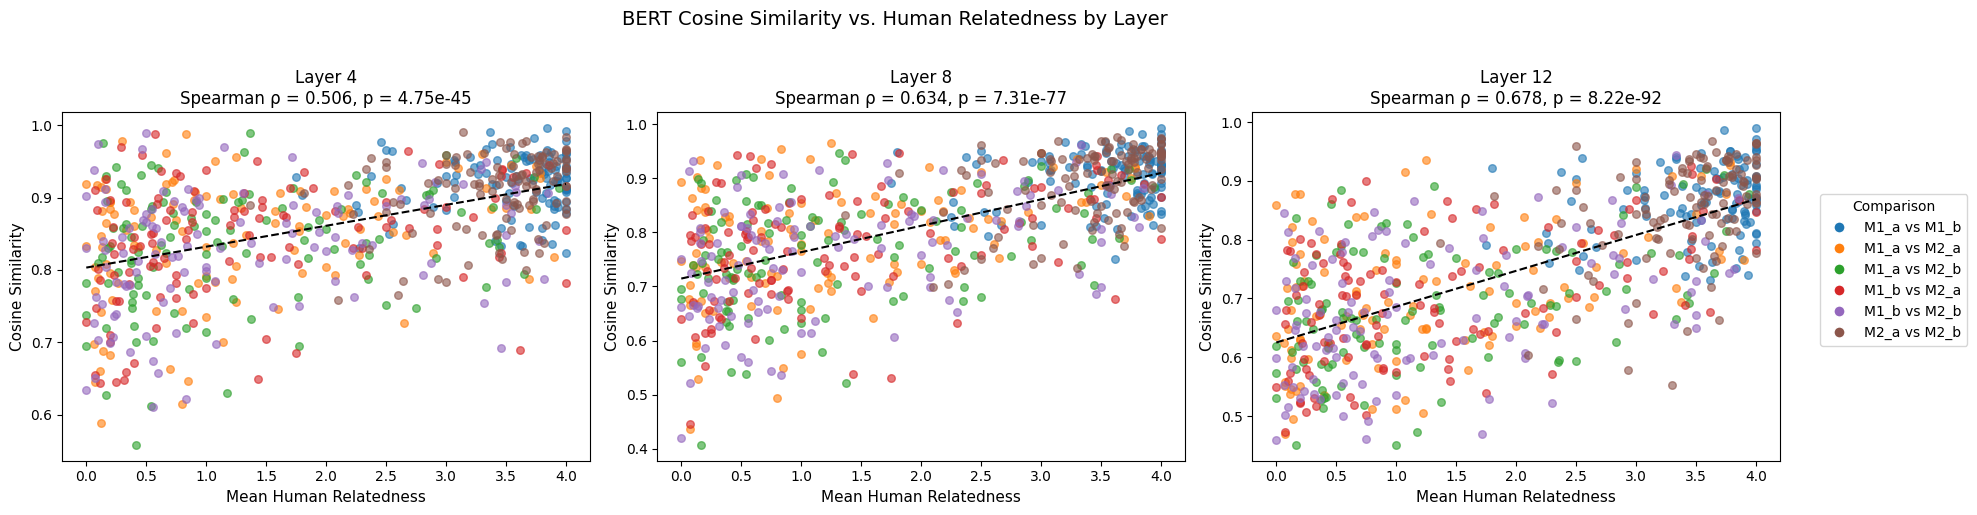

In [961]:
# your code here

plot_df = sim_df.dropna(subset=["mean_relatedness"]).copy()
layers = ["cosine_sim_layer_4", "cosine_sim_layer_8", "cosine_sim_layer_12"]
layer_labels = ["Layer 4", "Layer 8", "Layer 12"]

# Color palette — one colour per comparison type
comparisons = sorted(plot_df["comparison"].unique())
palette = dict(zip(comparisons, sns.color_palette("tab10", len(comparisons))))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, layer, label in zip(axes, layers, layer_labels):
    for comp, group in plot_df.groupby("comparison"):
        ax.scatter(
            group["mean_relatedness"],
            group[layer],
            label=comp,
            color=palette[comp],
            alpha=0.6,
            s=30
        )

    # Overall regression line
    x = plot_df["mean_relatedness"]
    y = plot_df[layer]
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--")

    # Spearman r annotation
    r, p = spearmanr(x, y)
    ax.set_title(f"{label}\nSpearman ρ = {r:.3f}, p = {p:.2e}", fontsize=12)
    ax.set_xlabel("Mean Human Relatedness", fontsize=11)
    ax.set_ylabel("Cosine Similarity", fontsize=11)

# Single shared legend outside the plots
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=palette[c], markersize=8, label=c)
    for c in comparisons
]
fig.legend(handles=handles, title="Comparison", bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=10)

plt.suptitle("BERT Cosine Similarity vs. Human Relatedness by Layer", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("bert_layers_vs_human.png", dpi=150, bbox_inches="tight")
plt.show()

### Reflect on the correlations and on the visualisations. What can you observe and infer in terms of which layer(s) might be capturing meaning best? Is there one way to determine that (i.e., what does 'capturing meanings' mean?)? Contrast and compare the layers. [5 points]

The Spearman p correlation between BERT's embeddings and human judgment goes from 0.506 (layer 4) → 0.634 (layer 8) → 0.678 (layer 12). That means deeper layers capture human-like judgment disctinctions better.

However, answering the question whether BERT captures meaning well is not so straightforward. The model might be good at the specific task we just conducted, but completely fail on a different task.

